# UNet Training with CLAHE for Optic Disc/Cup Segmentation

This notebook trains a UNet model with CLAHE (Contrast Limited Adaptive Histogram Equalization) preprocessing for enhanced fundus image segmentation.

## 1. Setup and Imports

In [4]:
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt

# Add src to path
project_root = Path.cwd().parent
sys.path.append(str(project_root / 'src'))

from training.train import train_model, plot_training_history

print(f"Project root: {project_root}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

Project root: /home/robolab/dev/CAP5410-roi-enhancer-odoc
PyTorch version: 2.8.0+cu128
CUDA available: True
CUDA device: NVIDIA GeForce RTX 2080 Ti


## 2. Training Configuration

In [5]:
# Training hyperparameters with CLAHE
config = {
    'root_dir': str(project_root),
    'num_epochs': 3, # TODO: 100
    'batch_size': 16,
    'learning_rate': 1e-4,
    'image_size': 256,
    'base_channels': 64,
    'num_workers': 4,
    'save_dir': str(project_root / 'checkpoints_clahe'),
    'filter_incomplete': True,
    'use_clahe': True  # Enable CLAHE for contrast enhancement
}

print("Training Configuration with CLAHE:")
print("=" * 50)
for key, value in config.items():
    print(f"{key:20s}: {value}")
print("\n✨ Using CLAHE (Contrast Limited Adaptive Histogram Equalization)")
print("   - Improves local contrast in fundus images")
print("   - Enhances disc/cup boundaries")
print("   - Cup weight=2.0 for better Cup segmentation")

Training Configuration with CLAHE:
root_dir            : /home/robolab/dev/CAP5410-roi-enhancer-odoc
num_epochs          : 3
batch_size          : 16
learning_rate       : 0.0001
image_size          : 256
base_channels       : 64
num_workers         : 4
save_dir            : /home/robolab/dev/CAP5410-roi-enhancer-odoc/checkpoints_clahe
filter_incomplete   : True
use_clahe           : True

✨ Using CLAHE (Contrast Limited Adaptive Histogram Equalization)
   - Improves local contrast in fundus images
   - Enhances disc/cup boundaries
   - Cup weight=2.0 for better Cup segmentation


## 3. Train the Model

In [6]:
# Clear the dataset cache before training to ensure filter_incomplete works correctly
from data_loader.dataset import GlaucomaDataset
GlaucomaDataset._split_cache.clear()

# Train the model
model, history = train_model(**config)

Using device: cuda
Random seeds set for reproducible training
Using CLAHE for contrast enhancement

Loading datasets...
Filtering incomplete masks...
  Filtered out 234 images with incomplete masks
TRAIN split: 1845 samples
VAL split: 395 samples
TEST split: 396 samples

Initializing model...
Model parameters: 31,043,651

Starting training for 3 epochs...

Epoch 1/3
--------------------------------------------------------------------------------


Validation: 100%|██████████| 25/25 [00:04<00:00,  5.90it/s, loss=0.4445, iou_bg=0.7007, iou_disc=0.6173, iou_cup=0.5627]



Epoch 1 Summary:
  Train Loss: 0.5118 | Val Loss: 0.4513
  Train IoU - BG: 0.6305, Disc: 0.5711, Cup: 0.5279
  Val IoU   - BG: 0.6420, Disc: 0.6158, Cup: 0.5801
  Learning Rate: 0.000100
  ✓ Saved best model (val_loss: 0.4513)

Epoch 2/3
--------------------------------------------------------------------------------


Validation: 100%|██████████| 25/25 [00:04<00:00,  5.87it/s, loss=0.3562, iou_bg=0.7377, iou_disc=0.6858, iou_cup=0.6122]



Epoch 2 Summary:
  Train Loss: 0.3918 | Val Loss: 0.3539
  Train IoU - BG: 0.6964, Disc: 0.6589, Cup: 0.6261
  Val IoU   - BG: 0.7010, Disc: 0.7014, Cup: 0.6421
  Learning Rate: 0.000100
  ✓ Saved best model (val_loss: 0.3539)

Epoch 3/3
--------------------------------------------------------------------------------


Validation: 100%|██████████| 25/25 [00:04<00:00,  5.89it/s, loss=0.3398, iou_bg=0.7300, iou_disc=0.6736, iou_cup=0.6086]



Epoch 3 Summary:
  Train Loss: 0.3509 | Val Loss: 0.3516
  Train IoU - BG: 0.7258, Disc: 0.6858, Cup: 0.6502
  Val IoU   - BG: 0.6828, Disc: 0.6793, Cup: 0.6283
  Learning Rate: 0.000100
  ✓ Saved best model (val_loss: 0.3516)

Training completed!
Best validation loss: 0.3516


## 4. Visualize Training Progress

Plot saved to /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/training_history_clahe.png


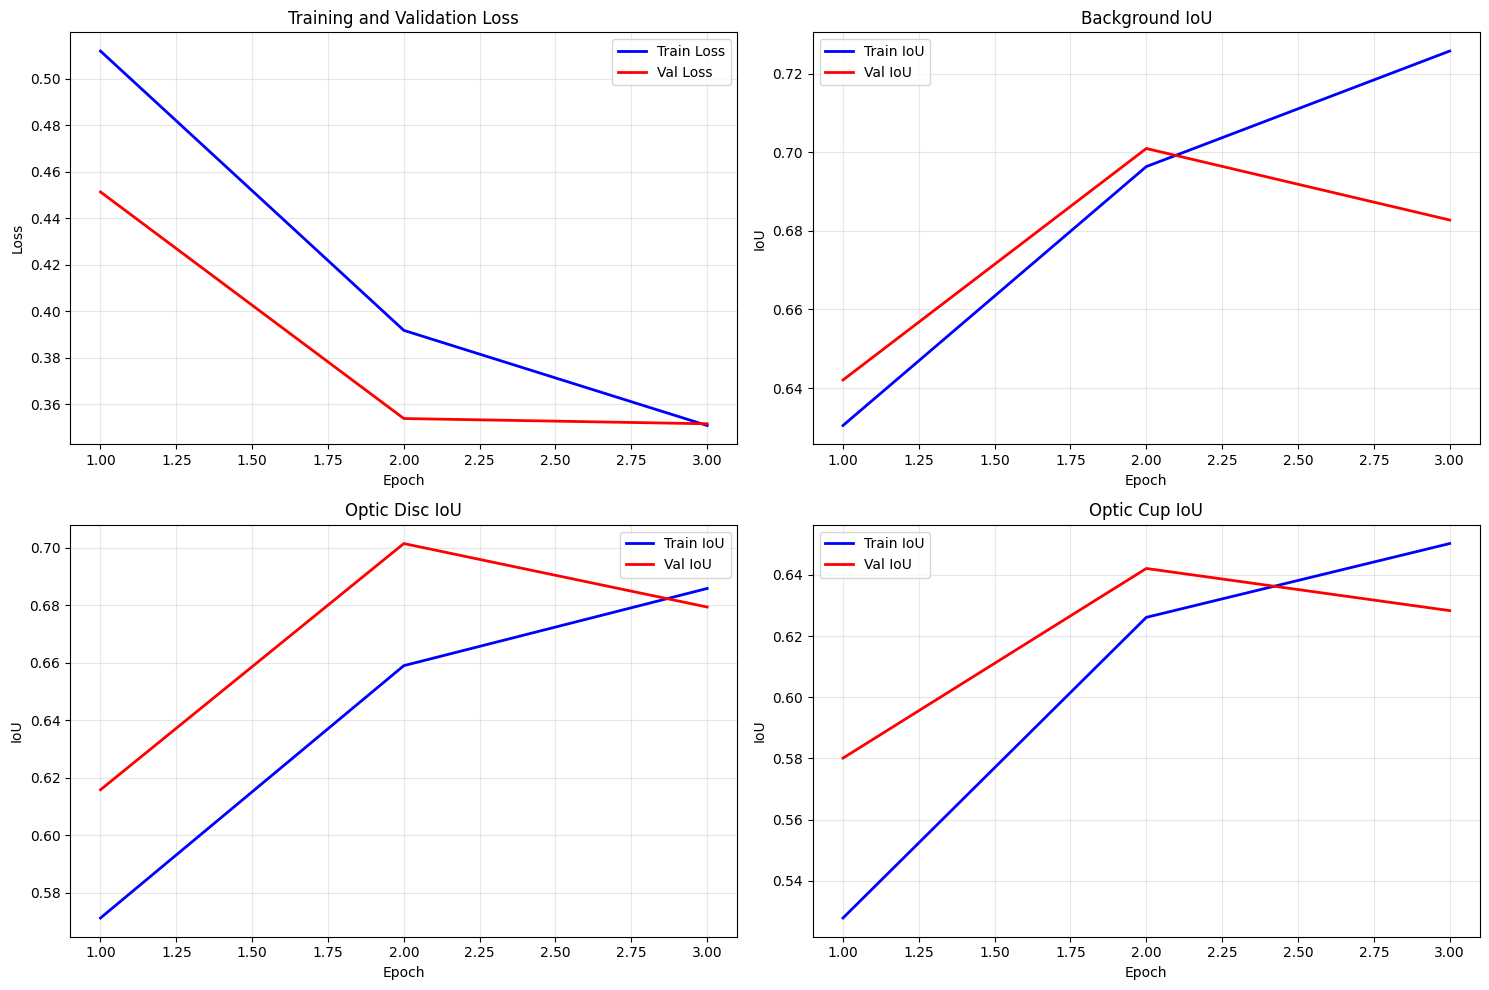

In [7]:
# Plot training history
fig = plot_training_history(
    history, 
    save_path=str(project_root / 'results' / 'training_history_clahe.png')
)
plt.show()

## 5. Print Final Metrics

In [8]:
print("\n" + "=" * 80)
print("FINAL TRAINING RESULTS (CLAHE)")
print("=" * 80)

final_epoch = len(history['train_loss'])
print(f"\nTotal Epochs: {final_epoch}")

print("\nFinal Training Metrics:")
print(f"  Loss:        {history['train_loss'][-1]:.4f}")
print(f"  IoU (BG):    {history['train_iou_bg'][-1]:.4f}")
print(f"  IoU (Disc):  {history['train_iou_disc'][-1]:.4f}")
print(f"  IoU (Cup):   {history['train_iou_cup'][-1]:.4f}")

print("\nFinal Validation Metrics:")
print(f"  Loss:        {history['val_loss'][-1]:.4f}")
print(f"  IoU (BG):    {history['val_iou_bg'][-1]:.4f}")
print(f"  IoU (Disc):  {history['val_iou_disc'][-1]:.4f}")
print(f"  IoU (Cup):   {history['val_iou_cup'][-1]:.4f}")

print("\nBest Validation Loss:")
best_epoch = history['val_loss'].index(min(history['val_loss'])) + 1
best_val_loss = min(history['val_loss'])
print(f"  Epoch: {best_epoch}")
print(f"  Loss:  {best_val_loss:.4f}")

print("\n" + "=" * 80)


FINAL TRAINING RESULTS (CLAHE)

Total Epochs: 3

Final Training Metrics:
  Loss:        0.3509
  IoU (BG):    0.7258
  IoU (Disc):  0.6858
  IoU (Cup):   0.6502

Final Validation Metrics:
  Loss:        0.3516
  IoU (BG):    0.6828
  IoU (Disc):  0.6793
  IoU (Cup):   0.6283

Best Validation Loss:
  Epoch: 3
  Loss:  0.3516



## 6. Save Training History

In [9]:
import json

# Save history as JSON
results_dir = project_root / 'results'
results_dir.mkdir(exist_ok=True, parents=True)

history_path = results_dir / 'training_history_clahe.json'
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)

print(f"Training history saved to: {history_path}")

Training history saved to: /home/robolab/dev/CAP5410-roi-enhancer-odoc/results/training_history_clahe.json
